# Monthly station climate

NOAA's Global Summary of the Month (GSOM) condenses each land station's daily
GHCN-Daily record into one row per calendar month: total precipitation, mean
temperature, extremes, and counts of days past thresholds. NCEI publishes it
through its Access Data Service, and one request returns one CSV with a row
per station and month.

This walkthrough pulls five years of monthly precipitation and mean
temperature at Will Rogers World Airport in Oklahoma City, January 2020 to
December 2024. It needs `usdata[pandas]` and matplotlib, and runs in a few
seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:55:14+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one station, two variables, and a window. GSOM selects
every UTC calendar month the window touches, in full: 6 to 7 May selects all
of May, and 31 May to 1 June selects both months. `USW00013967` is the
airport's GHCN station ID; a `bbox` or `place` in place of `stations` finds
stations through NCEI's search service. `units: metric` asks for millimetres
and degrees Celsius.

In [2]:
print(manifest.read_text())

name: okc-monthly-climate
sources:
  - dataset: noaa:gsom
    start: 2020-01-01
    end: 2024-12-31
    variables: [PRCP, TAVG]
    params:
      stations: USW00013967
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. Later pulls reuse the pin and the cache.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: global-summary-of-the-month_2020-01-01_2024-12-31_de68833a1ecf.csv
Bytes: 4200
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-summary-of-the-month&stations=USW00013967&startDate=2020-01-01&endDate=2024-12-31&format=csv&units=metric&includeStationLocation=1&dataTypes=PRCP%2CTAVG
Retrieved (UTC): 2026-09-24T05:55:14+00:00
Checksum: sha256:c9d6f9135d27bc26602fd74b00ad9451a00f6985323ffa25da18da6ced04ef8d


## Open

The generic CSV reader returns a DataFrame with one row per month. `DATE` is a
`YYYY-MM` label for a whole month, not a timestamp; parsing it as a monthly
period keeps that meaning. `PRCP` is the month's total in millimetres and
`TAVG` its mean in degrees Celsius. NCEI's CSV has no units row, so the units
come from the request. Each row repeats the station's latitude, longitude, and
elevation in metres.

In [4]:
frame = item.open()
frame["MONTH"] = pd.PeriodIndex(frame["DATE"], freq="M")
print(f"{len(frame)} rows, {frame['MONTH'].min()} to {frame['MONTH'].max()}")
frame[["STATION", "LATITUDE", "LONGITUDE", "ELEVATION", "DATE", "PRCP", "TAVG"]].head()

60 rows, 2020-01 to 2024-12


,STATION,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,TAVG
0,USW00013967,35.38843,-97.60035,389.9,2020-01,79.8,5.9
1,USW00013967,35.38843,-97.60035,389.9,2020-02,16.5,5.3
2,USW00013967,35.38843,-97.60035,389.9,2020-03,127.8,13.0
3,USW00013967,35.38843,-97.60035,389.9,2020-04,51.5,14.1
4,USW00013967,35.38843,-97.60035,389.9,2020-05,103.7,19.8


## A first look

The same twelve calendar months, five times over: each year's monthly mean
temperature as a line, and each year's monthly precipitation as a dot beside
the five-year median.

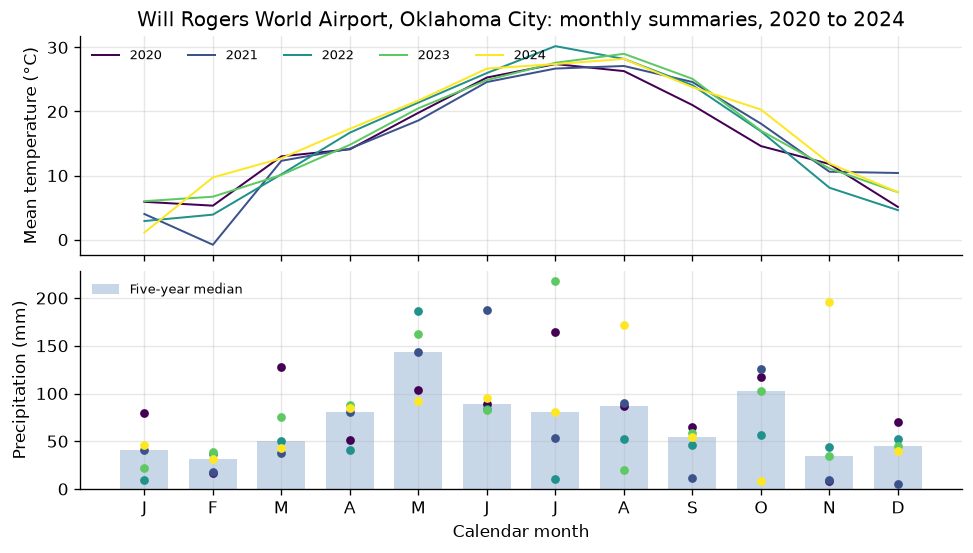

In [5]:
frame["YEAR"] = frame["MONTH"].dt.year
frame["CALENDAR_MONTH"] = frame["MONTH"].dt.month
labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
years = sorted(frame["YEAR"].unique())
shades = plt.cm.viridis([i / (len(years) - 1) for i in range(len(years))])

fig, (warm, wet) = plt.subplots(2, 1, sharex=True, layout="constrained")
for year, shade in zip(years, shades, strict=True):
    rows = frame[frame["YEAR"] == year]
    warm.plot(rows["CALENDAR_MONTH"], rows["TAVG"], color=shade, linewidth=1.2, label=str(year))
    wet.scatter(rows["CALENDAR_MONTH"], rows["PRCP"], color=shade, s=18, zorder=3)
median = frame.groupby("CALENDAR_MONTH")["PRCP"].median()
wet.bar(
    median.index, median.values, color="#2563a6", alpha=0.25, width=0.7, label="Five-year median"
)
warm.set_ylabel("Mean temperature (°C)")
warm.set_title("Will Rogers World Airport, Oklahoma City: monthly summaries, 2020 to 2024")
warm.legend(ncols=5, fontsize=8, loc="upper left", frameon=False)
wet.set_ylabel("Precipitation (mm)")
wet.legend(fontsize=8, loc="upper left", frameon=False)
wet.set_xticks(range(1, 13), labels)
wet.set_xlabel("Calendar month")
plt.show()

In [6]:
spread = frame.groupby("CALENDAR_MONTH").agg(
    TAVG_RANGE=("TAVG", lambda values: values.max() - values.min()),
    PRCP_MIN=("PRCP", "min"),
    PRCP_MAX=("PRCP", "max"),
)
calm, rough = spread["TAVG_RANGE"].idxmin(), spread["TAVG_RANGE"].idxmax()
widest = spread["PRCP_MAX"].sub(spread["PRCP_MIN"]).idxmax()
print(
    "Year-to-year range of the monthly mean temperature: "
    f"{spread.loc[calm, 'TAVG_RANGE']:.1f} °C in month {calm}, "
    f"{spread.loc[rough, 'TAVG_RANGE']:.1f} °C in month {rough}"
)
print(
    f"Precipitation in month {widest} ranged {spread.loc[widest, 'PRCP_MIN']:.1f} to "
    f"{spread.loc[widest, 'PRCP_MAX']:.1f} mm across the five years"
)

Year-to-year range of the monthly mean temperature: 2.1 °C in month 6, 10.5 °C in month 2
Precipitation in month 7 ranged 10.7 to 217.9 mm across the five years


The seasonal cycle, more than 20 °C from January to July, repeats closely in
summer: June's mean stayed within about 2 °C across the five years. Winter
varies more, with February 2021 below freezing and February 2024 near 10 °C.
Precipitation is far less regular: one calendar month can differ twentyfold
between years. Five years at one station show that spread; they are not a
climate normal, which the
[Climate Normals](https://usdata.dev/datasets/noaa/climate-normals/) dataset
provides for 1991 to 2020.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:gsom
  Lawrimore, Jay H.; Ray, Ron; Applequist, Scott; Korzeniewski, Bryant; Menne, Matthew J. (2016): Global Summary of the Month (GSOM), Version 1. NOAA National Centers for Environmental Information. https://doi.org/10.7289/V5QV3JJ5
  homepage: https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-month
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00946/html
  retrieved: 2026-09-24; 1 checksummed asset (4,200 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- The CSV carries no units. The request's `units: metric` used to be the only
  record of whether `PRCP` is millimetres or inches; the frame now keeps it in
  `attrs["usdata"]["properties"]`.
- The window widens to whole UTC months without saying so. A query for one
  week in May returns the May row, and the asset's time bounds cover all of
  May rather than the dates asked for.
- `DATE` is text such as `2024-05`. Grouping by calendar month needs a parse
  first; `pd.PeriodIndex(..., freq="M")` keeps it a month rather than
  pretending it is the first day of one.
- Changing the window in a locked manifest is reported as an input change
  until the pull is repeated with `force=True`, which replaces the lockfile.
  That protects the pin but is a step to remember when exploring.